# **CAPA DE GOBERNANZA**



# **Objetivo de la Capa**

La capa de Gobernanza tiene como objetivo consolidar indicadores institucionales, socioeconómicos, demográficos y de cobertura de servicios públicos que permitan caracterizar el contexto territorial de los municipios de estudio. Esta información constituye una dimensión complementaria a las variables climáticas, hidráulicas y de percepción, aportando factores estructurales que influyen en la gestión sostenible del recurso hídrico y fortaleciendo los procesos de análisis, interoperabilidad y modelado predictivo del Framework.

#  **Justificación Científica**

La gestión del agua no depende únicamente de variables hidrológicas o climáticas. Diversos estudios sobre Gestión Integrada del Recurso Hídrico (GIRH) demuestran que las capacidades institucionales, las condiciones socioeconómicas, la infraestructura de servicios públicos y las características demográficas influyen directamente sobre la disponibilidad, acceso, calidad y sostenibilidad del recurso hídrico.

Por esta razón, el Framework incorpora una capa específica de Gobernanza que integra información proveniente de fuentes oficiales abiertas del departamento de Cundinamarca y entidades nacionales, permitiendo representar el contexto institucional y territorial mediante indicadores de población, densidad poblacional, producto interno bruto, desempeño institucional, cobertura de acueducto, cobertura de alcantarillado, acceso al agua potable, saneamiento básico y tratamiento de aguas residuales.

La integración de estos indicadores amplía la capacidad analítica del Framework al permitir estudiar la interacción entre variables ambientales, sociales e institucionales bajo un enfoque multidimensional, favoreciendo posteriormente la aplicación de modelos de Ciencia de Datos e Inteligencia Artificial para apoyar la toma de decisiones.

# **Alcance de la capa**

La capa de Gobernanza consolida información oficial correspondiente a los municipios de Chía, Sopó, Tocancipá y Villapinzón para el período comprendido entre 2020 y 2024, organizando los datos bajo una estructura estandarizada de un registro por municipio y año.

Durante el proceso de construcción se realizó la integración de múltiples conjuntos de datos abiertos, la selección de indicadores con cobertura temporal suficiente, la transformación de la información desde formato longitudinal hacia una matriz estructurada en formato ancho y la estandarización de variables para garantizar su interoperabilidad con las demás capas del Framework.

Como resultado, la capa genera un conjunto de datos consistente que podrá integrarse directamente con las capas Climática, Hidráulica, Calidad del Agua, Consumo, Percepción e Identificación, conformando el dataset maestro que servirá como base para los procesos de análisis exploratorio, minería de datos, modelado predictivo mediante redes LSTM y demás algoritmos de aprendizaje automático contemplados en el proyecto de investigación.


#  **Capa**

*   **M0 Configuración**
    *   Montaje, importación de librerías y definición de rutas globales.
*   **M1 Lectura**
    *   Conexión e ingesta del archivo original.
*   **M2 Validación Estructural**
    *   Verificación de dimensiones, nombres de columnas esperados y tipos de datos iniciales.
*   **M3 Estandarización**
    *   Limpieza de texto, formateo de fechas, manejo de nulos y renombrado bajo buenas prácticas (*snake_case*).
*   **M4 Gobierno del Dato**
    *   Aplicación de reglas de negocio, validación de rangos lógicos y seguridad.
*   **M5 Metadata**
    *   Generación del registro técnico del dataset (esquema, autor, fecha de ejecución y linaje).
*   **M6 Diccionario**
    *   Creación del diccionario de datos con las definiciones técnicas y de negocio de cada variable.
*   **M7 Auditoría**
    *   Control de registros (filas procesadas vs. descartadas) y logs de errores.
*   **M8 Indicadores**
    *   Cálculo de métricas de calidad de datos (completitud, exactitud y duplicidad).
*   **M9 EDA**
    *   Análisis Exploratorio de Datos con estadísticas descriptivas y generación de gráficos visuales.
*   **M10 README**
    *   Documentación general del proceso (este componente).
*   **Exportación Final**
    *   Escritura de todos los entregables en la estructura de carpetas destino.

---

# **Estructura de Archivos Generada**

```text
07_Capa_Gobernanza/
├── 01_Capa_Gobernanza_V1.xlsx        ← Evidencia original (Datos crudos)
├── 02_Capa_Gobernanza_Framework.xlsx ← Dataset estandarizado y limpio (Listo para usar)
├── 03_Metadata.xlsx                  ← Registro de propiedades y esquema del dataset
├── 04_Diccionario_Datos.xlsx         ← Definición técnica y de negocio de las variables
├── 05_Auditoria.xlsx                 ← Logs de procesamiento y control de registros
├── 06_Indicadores.xlsx               ← Métricas de calidad del dato
├── 07_EDA.xlsx                       ← Reporte estadístico del Análisis Exploratorio
├── 08_README.md                      ← Copia de respaldo de esta documentación
└── Graficos/                         ← Artefactos visuales exportados en el M9

## **M0 – Configuración**

In [ ]:
import pandas as pd
import numpy as np
import hashlib
from datetime import datetime
import os

# ============================================================
# FRAMEWORK V7
# FRAMEWORK CORE
# GENERADOR UNIVERSAL DE CAPAS
# ============================================================

NOMBRE_CAPA = "Gobernanza"

CODIGO_CAPA = "GOB"

VERSION = "1.0"

RESPONSABLE = "Juan Carlos Riatiga"

FUENTE = (
    "Portal de Datos Abiertos de Cundinamarca "
    "(Servicios Públicos, Economía y Descripción General)"
)

URL_FUENTE = (
    "https://datosmintic-cundinamarca-map.hub.arcgis.com/"
)

ARCHIVO = (
    "https://raw.githubusercontent.com/jriatiga/dataset/"
    "refs/heads/main/proyectoGradoV4/"
    "07_Capa_Gobernanza/"
    "01_Capa_Gobernanza_V1.xlsx"
)

## **M1 – Lectura**

In [ ]:
df=pd.read_excel(ARCHIVO)

print(df.head())

print(df.shape)

   Nodo  COD_MUN MUNICIPIO  Anio  POBLACION TOTAL  DENSIDAD POBLACIONAL  \
0  CHIA    25175      CHIA  2020              NaN                   NaN   
1  CHIA    25175      CHIA  2021         148415.0               1952.83   
2  CHIA    25175      CHIA  2022         153130.0               2014.87   
3  CHIA    25175      CHIA  2023         158258.0               2082.34   
4  CHIA    25175      CHIA  2024         163306.0               2148.76   

   PORCENTAJE POBLACION URBANA  PORCENTAJE POBLACION RURAL  \
0                        83.11                       16.89   
1                        83.72                       16.28   
2                        84.17                       15.83   
3                        84.58                       15.42   
4                        84.97                       15.03   

   PRODUCTO INTERNO BRUTO DEPARTAMENTAL  INDICE DE DESEMPENO INSTITUCIONAL  \
0                           3503.635640                                NaN   
1                   

## **M2 – Validación estructural**

In [ ]:
print("="*70)
print("M2 - VALIDACIÓN ESTRUCTURAL")
print("="*70)

# ============================================================
# DIMENSIONES
# ============================================================

print("\nDIMENSIONES")
print("-"*70)
print(f"Filas    : {df.shape[0]}")
print(f"Columnas : {df.shape[1]}")

# ============================================================
# COLUMNAS
# ============================================================

print("\nCOLUMNAS DEL DATASET")
print("-"*70)

for i, c in enumerate(df.columns,1):
    print(f"{i}. {c}")

# ============================================================
# NULOS
# ============================================================

print("\nVALORES NULOS")
print("-"*70)
print(df.isnull().sum())

# ============================================================
# DUPLICADOS
# ============================================================

print("\nREGISTROS DUPLICADOS")
print("-"*70)
print(df.duplicated().sum())

# ============================================================
# TIPOS
# ============================================================

print("\nTIPOS DE DATOS")
print("-"*70)
print(df.dtypes)

# ============================================================
# MEMORIA
# ============================================================

print("\nUSO DE MEMORIA")
print("-"*70)
print(df.memory_usage(deep=True))

# ============================================================
# VARIABLES CATEGÓRICAS
# ============================================================

print("\nVARIABLES CATEGÓRICAS")
print("-"*70)

categoricas=df.select_dtypes(include="object").columns

for c in categoricas:

    print(f"\n{c}")
    print(df[c].value_counts())

# ============================================================
# VARIABLES NUMÉRICAS
# ============================================================

print("\nVARIABLES NUMÉRICAS")
print("-"*70)

print(df.describe())

# ============================================================
# COBERTURA TEMPORAL
# ============================================================

print("\nCOBERTURA TEMPORAL")
print("-"*70)

print("Inicio :",df["Anio"].min())
print("Fin    :",df["Anio"].max())

# ============================================================
# MUNICIPIOS
# ============================================================

print("\nMUNICIPIOS DISPONIBLES")
print("-"*70)

print(df["MUNICIPIO"].value_counts())

# ============================================================
# VARIABLES DE GOBERNANZA
# ============================================================

print("\nVARIABLES DE GOBERNANZA")
print("-"*70)

variables=[c for c in df.columns if c not in ["COD_MUN","MUNICIPIO","Anio"]]

for v in variables:

    print(v)

# ============================================================
# PORCENTAJE DE COMPLETITUD
# ============================================================

print("\nCOMPLETITUD (%)")
print("-"*70)

completitud=((1-df.isnull().mean())*100).round(2)

print(completitud)

print("\n")
print("="*70)
print("VALIDACIÓN FINALIZADA")
print("="*70)

M2 - VALIDACIÓN ESTRUCTURAL

DIMENSIONES
----------------------------------------------------------------------
Filas    : 20
Columnas : 19

COLUMNAS DEL DATASET
----------------------------------------------------------------------
1. Nodo
2. COD_MUN
3. MUNICIPIO
4. Anio
5. POBLACION TOTAL
6. DENSIDAD POBLACIONAL
7. PORCENTAJE POBLACION URBANA
8. PORCENTAJE POBLACION RURAL
9. PRODUCTO INTERNO BRUTO DEPARTAMENTAL
10. INDICE DE DESEMPENO INSTITUCIONAL
11. ACCESO A AGUA POTABLE ADECUADO
12. PORCENTAJE DE LA POBLACION CON ACCESO A METODOS DE SANEAMIENTO ADECUADOS
13. COBERTURA DE ACUEDUCTO URBANO
14. COBERTURA DE ACUEDUCTO RURAL
15. COBERTURA DE ALCANTARILLADO URBANO
16. COBERTURA DE ALCANTARILLADO RURAL
17. CONTINUIDAD DE ACUEDUCTO URBANO
18. CALIDAD DEL AGUA
19. AGUAS RESIDUALES TRATADAS

VALORES NULOS
----------------------------------------------------------------------
Nodo                                                                         0
COD_MUN                              

**Documentación Metodológica: Gestión de Valores Nulos**

> ⚠️ **Nota Crítica para el Framework:** La presencia de valores nulos en el dataset **no se debe a un error en el proceso de extracción, transformación y carga (ETL)**, sino a las dinámicas estructurales de publicación de la fuente oficial.

Modificar o forzar estos datos alteraría la realidad metodológica de la investigación. Por ende, se documentan las siguientes restricciones temporales por variable:

| Variable / Indicador | Comportamiento en la Fuente Oficial | Impacto en el Modelo |
| :--- | :--- | :--- |
| **Población Total** | Sólo existe registro desde **2021** en adelante. | Restringe la serie temporal demográfica. |
| **Densidad Poblacional** | Sólo existe registro desde **2021** en adelante. | Sigue la misma ventana de Población Total. |
| **Índice de Desempeño Institucional** | Únicamente publicado para **un año** específico. | Funciona como una constante o foto fija del periodo. |
| **Continuidad de Acueducto Urbano** | Solamente existen datos para **2023 - 2024**. | Ventana de tiempo crítica y reciente. |
| **Calidad del Agua** | Únicamente disponible para **2023 - 2024**. | Ventana de tiempo crítica y reciente. |
| **Aguas Residuales Tratadas** | Únicamente disponible para **2023 - 2024**. | Ventana de tiempo crítica y reciente. |

---

**📌 Justificación de la Decisión Técnica**

1. **Fidelidad de la Fuente:** Documentar estas ausencias protege la integridad científica del Framework V7, demostrando que se conocen las limitaciones de la información pública territorial.
2. **Estrategia para el LSTM:** Al alimentar la red neuronal de memoria a corto y largo plazo (LSTM), el diseño de las capas deberá considerar estas ventanas temporales fragmentadas (ej. usar técnicas de padding, máscaras de nulos, o sincronizar el entrenamiento basándose en el bloque robusto de los años más recientes).

## **M3 – Estandarización**

In [ ]:
# ============================================================
# M3 - ESTANDARIZACIÓN
# CAPA GOBERNANZA
# ============================================================

print("="*70)
print("M3 - ESTANDARIZACIÓN")
print("="*70)

# ============================================================
# 1. Normalización de nombres de municipios
# ============================================================

df["Nodo"] = (
    df["Nodo"]
    .astype(str)
    .str.upper()
    .str.strip()
)

df["MUNICIPIO"] = (
    df["MUNICIPIO"]
    .astype(str)
    .str.upper()
    .str.strip()
)

# ============================================================
# 2. Conversión de tipos de datos
# ============================================================

df["Anio"] = df["Anio".strip()].astype(int)
df["COD_MUN"] = df["COD_MUN".strip()].astype(int)

# ============================================================
# 3. Variables numéricas
# ============================================================

variables_numericas = [

    "POBLACION TOTAL",
    "DENSIDAD POBLACIONAL",
    "PORCENTAJE POBLACION URBANA",
    "PORCENTAJE POBLACION RURAL",
    "PRODUCTO INTERNO BRUTO DEPARTAMENTAL",
    "INDICE DE DESEMPENO INSTITUCIONAL",
    "ACCESO A AGUA POTABLE ADECUADO",
    "PORCENTAJE DE LA POBLACION CON ACCESO A METODOS DE SANEAMIENTO ADECUADOS",
    "COBERTURA DE ACUEDUCTO URBANO",
    "COBERTURA DE ACUEDUCTO RURAL",
    "COBERTURA DE ALCANTARILLADO URBANO",
    "COBERTURA DE ALCANTARILLADO RURAL",
    "CONTINUIDAD DE ACUEDUCTO URBANO",
    "CALIDAD DEL AGUA",
    "AGUAS RESIDUALES TRATADAS"

]

for col in variables_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ============================================================
# 4. Eliminación de espacios en nombres de columnas
# ============================================================

df.columns = [c.strip() for c in df.columns]

# ============================================================
# 5. Ordenamiento
# ============================================================

df = (
    df
    .sort_values(["Nodo", "Anio"])
    .reset_index(drop=True)
)

# ============================================================
# 6. Creación de identificadores del Framework
# ============================================================

if "ID_Registro" not in df.columns:
    df.insert(
        0,
        "ID_Registro",
        [
            f"{CODIGO_CAPA}-{str(i).zfill(7)}"
            for i in range(1, len(df)+1)
        ]
    )

if "ID_Capa" not in df.columns:
    df.insert(
        1,
        "ID_Capa",
        CODIGO_CAPA
    )

# ============================================================
# 6. Fecha estándar del Framework
# ============================================================

if "Fecha" not in df.columns:
    df.insert(
        3,
        "Fecha",
        pd.to_datetime(
            df["Anio"].astype(str) + "-12-31"
        )
    )

print("\nProceso finalizado correctamente.")

print("\nDimensiones:", df.shape)

display(df.head())

M3 - ESTANDARIZACIÓN

Proceso finalizado correctamente.

Dimensiones: (20, 22)


,ID_Registro,ID_Capa,Nodo,Fecha,COD_MUN,MUNICIPIO,Anio,POBLACION TOTAL,DENSIDAD POBLACIONAL,PORCENTAJE POBLACION URBANA,...,INDICE DE DESEMPENO INSTITUCIONAL,ACCESO A AGUA POTABLE ADECUADO,PORCENTAJE DE LA POBLACION CON ACCESO A METODOS DE SANEAMIENTO ADECUADOS,COBERTURA DE ACUEDUCTO URBANO,COBERTURA DE ACUEDUCTO RURAL,COBERTURA DE ALCANTARILLADO URBANO,COBERTURA DE ALCANTARILLADO RURAL,CONTINUIDAD DE ACUEDUCTO URBANO,CALIDAD DEL AGUA,AGUAS RESIDUALES TRATADAS
0,GOB-0000001,GOB,CHIA,2020-12-31,25175,CHIA,2020,NaN,NaN,83.11,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,GOB-0000002,GOB,CHIA,2021-12-31,25175,CHIA,2021,148415.0,1952.83,83.72,...,NaN,100.0,99.00,100.0,100.0,84.66,61.07,NaN,NaN,NaN
2,GOB-0000003,GOB,CHIA,2022-12-31,25175,CHIA,2022,153130.0,2014.87,84.17,...,NaN,100.0,99.00,1.0,100.0,98.09,59.83,NaN,NaN,NaN
3,GOB-0000004,GOB,CHIA,2023-12-31,25175,CHIA,2023,158258.0,2082.34,84.58,...,NaN,100.0,98.85,1.0,100.0,99.00,1.00,24.0,25.00,69.0
4,GOB-0000005,GOB,CHIA,2024-12-31,25175,CHIA,2024,163306.0,2148.76,84.97,...,69.6,100.0,98.85,1.0,100.0,99.00,1.00,24.0,36.32,69.0


Observación M3 – Estandarización

En esta etapa se verificó la homogeneidad estructural de la capa de Gobernanza mediante la normalización de los identificadores territoriales (Nodo y MUNICIPIO), la conversión de los tipos de datos a formatos consistentes, la estandarización de las variables numéricas y el ordenamiento cronológico de los registros. No se realizaron imputaciones ni modificaciones sobre los valores faltantes, ya que estos corresponden a la disponibilidad histórica de los datos publicados por las fuentes oficiales. El resultado es un conjunto de datos uniforme y preparado para las etapas de gobierno del dato e integración con el dataset maestro del Framework.

## **M4 – Gobierno del Dato**

In [ ]:
# ============================================================
# M4 - GOBIERNO DEL DATO
# CAPA GOBERNANZA
# ============================================================

from datetime import datetime
import hashlib

print("="*70)
print("M4 - GOBIERNO DEL DATO")
print("="*70)

# ============================================================
# INFORMACIÓN GENERAL
# ============================================================

fecha_generacion = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

id_capa = hashlib.md5(
    f"{NOMBRE_CAPA}_{VERSION}_{fecha_generacion}".encode()
).hexdigest()

print("\nINFORMACIÓN GENERAL")
print("-"*70)

print("ID Capa              :", id_capa)
print("Nombre               :", NOMBRE_CAPA)
print("Código               :", CODIGO_CAPA)
print("Versión              :", VERSION)
print("Responsable          :", RESPONSABLE)
print("Fecha generación     :", fecha_generacion)

# ============================================================
# ORIGEN DEL DATO
# ============================================================

print("\nORIGEN")
print("-"*70)

print("Fuente principal     : Datos Abiertos Cundinamarca")
print("Tema                 : Gobernanza")
print("Departamento         : Cundinamarca")
print("Municipios           :", df["Nodo"].nunique())
print("Registros            :", len(df))

# ============================================================
# COBERTURA
# ============================================================

print("\nCOBERTURA")
print("-"*70)

print("Año inicial          :", df["Anio"].min())
print("Año final            :", df["Anio"].max())

print("\nNodos")

for nodo in sorted(df["Nodo"].unique()):
    print("-", nodo)

# ============================================================
# CALIDAD
# ============================================================

print("\nCALIDAD")
print("-"*70)

print("Duplicados           :", df.duplicated().sum())
print("Valores nulos        :", df.isna().sum().sum())

# ============================================================
# VARIABLES
# ============================================================

print("\nVARIABLES")
print("-"*70)

for columna in df.columns:
    print(columna)

print("\nGobierno del dato finalizado.")

M4 - GOBIERNO DEL DATO

INFORMACIÓN GENERAL
----------------------------------------------------------------------
ID Capa              : 81742c485946df40f4b9d169da1fac03
Nombre               : Gobernanza
Código               : GOB
Versión              : 1.0
Responsable          : Juan Carlos Riatiga
Fecha generación     : 2026-07-15 21:27:33

ORIGEN
----------------------------------------------------------------------
Fuente principal     : Datos Abiertos Cundinamarca
Tema                 : Gobernanza
Departamento         : Cundinamarca
Municipios           : 4
Registros            : 20

COBERTURA
----------------------------------------------------------------------
Año inicial          : 2020
Año final            : 2024

Nodos
- CHIA
- SOPO
- TOCANCIPA
- VILLAPINZON

CALIDAD
----------------------------------------------------------------------
Duplicados           : 0
Valores nulos        : 84

VARIABLES
----------------------------------------------------------------------
ID_Reg

## **M5 – Metadata**

In [ ]:
# ============================================================
# M5 - METADATA
# Generación de 03_Metadata.xlsx
# ============================================================

from datetime import datetime

print("="*70)
print("M5 - METADATA")
print("="*70)

metadata = {

    "Campo":[

        "Nombre_Capa",
        "Codigo_Capa",
        "Version",
        "Responsable",
        "Fecha_Generacion",
        "Archivo",
        "Fuente",
        "URL_Fuente",
        "Total_Registros",
        "Total_Columnas",
        "Cobertura_Inicial",
        "Cobertura_Final",
        "Total_Nodos",
        "Departamento",
        "Municipios",
        "Formato",
        "Variables",
        "Observaciones"

    ],

    "Valor":[

        NOMBRE_CAPA,
        CODIGO_CAPA,
        VERSION,
        RESPONSABLE,
        datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        ARCHIVO,

        "Portal de Datos Abiertos de Cundinamarca",

        URL_FUENTE,

        len(df),

        len(df.columns),

        df["Anio"].min(),

        df["Anio"].max(),

        df["Nodo"].nunique(),

        "Cundinamarca",

        ", ".join(sorted(df["Nodo"].unique())),

        "XLSX",

        len(df.columns),

        "Dataset construido mediante integración de indicadores de Servicios Públicos, Economía y Descripción General."

    ]

}

metadata_df = pd.DataFrame(metadata)

metadata_df.to_excel(

    "03_Metadata.xlsx",

    index=False

)

print()

print("Archivo generado correctamente.")

print("03_Metadata.xlsx")

display(metadata_df)

M5 - METADATA

Archivo generado correctamente.
03_Metadata.xlsx


,Campo,Valor
0,Nombre_Capa,Gobernanza
1,Codigo_Capa,GOB
2,Version,1.0
3,Responsable,Juan Carlos Riatiga
4,Fecha_Generacion,2026-07-15 21:27:37
5,Archivo,https://raw.githubusercontent.com/jriatiga/dat...
6,Fuente,Portal de Datos Abiertos de Cundinamarca
7,URL_Fuente,https://datosmintic-cundinamarca-map.hub.arcgi...
8,Total_Registros,20
9,Total_Columnas,22


## **M6 – Diccionario de Datos**

In [ ]:
# ============================================================
# M6 - DICCIONARIO DE DATOS
# Generación de 04_Diccionario_Datos.xlsx
# ============================================================

print("="*70)
print("M6 - DICCIONARIO DE DATOS")
print("="*70)

diccionario = [

    {
        "Variable":"Nodo",
        "Tipo":"Texto",
        "Descripción":"Nodo territorial utilizado como identificador principal del Framework.",
        "Unidad":"N/A",
        "Fuente":"Framework"
    },

    {
        "Variable":"COD_MUN",
        "Tipo":"Entero",
        "Descripción":"Código DANE del municipio.",
        "Unidad":"Código",
        "Fuente":"DANE"
    },

    {
        "Variable":"MUNICIPIO",
        "Tipo":"Texto",
        "Descripción":"Nombre oficial del municipio.",
        "Unidad":"N/A",
        "Fuente":"DANE"
    },

    {
        "Variable":"Fecha",
        "Tipo":"Fecha",
        "Descripción":"Fecha estandarizada del registro (31 de diciembre del año).",
        "Unidad":"AAAA-MM-DD",
        "Fuente":"Framework"
    },

    {
        "Variable":"Anio",
        "Tipo":"Entero",
        "Descripción":"Año de referencia del indicador.",
        "Unidad":"Año",
        "Fuente":"Framework"
    },

    {
        "Variable":"POBLACION TOTAL",
        "Tipo":"Numérico",
        "Descripción":"Población total estimada del municipio.",
        "Unidad":"Habitantes",
        "Fuente":"DANE"
    },

    {
        "Variable":"DENSIDAD POBLACIONAL",
        "Tipo":"Numérico",
        "Descripción":"Habitantes por kilómetro cuadrado.",
        "Unidad":"Hab/km²",
        "Fuente":"DANE"
    },

    {
        "Variable":"PORCENTAJE POBLACION URBANA",
        "Tipo":"Numérico",
        "Descripción":"Porcentaje de población ubicada en zona urbana.",
        "Unidad":"%",
        "Fuente":"DANE"
    },

    {
        "Variable":"PORCENTAJE POBLACION RURAL",
        "Tipo":"Numérico",
        "Descripción":"Porcentaje de población ubicada en zona rural.",
        "Unidad":"%",
        "Fuente":"DANE"
    },

    {
        "Variable":"PRODUCTO INTERNO BRUTO DEPARTAMENTAL",
        "Tipo":"Numérico",
        "Descripción":"Producto Interno Bruto municipal reportado por el conjunto de datos.",
        "Unidad":"Miles de millones de pesos",
        "Fuente":"DANE"
    },

    {
        "Variable":"INDICE DE DESEMPENO INSTITUCIONAL",
        "Tipo":"Numérico",
        "Descripción":"Índice de desempeño institucional del municipio.",
        "Unidad":"Índice",
        "Fuente":"Función Pública"
    },

    {
        "Variable":"ACCESO A AGUA POTABLE ADECUADO",
        "Tipo":"Numérico",
        "Descripción":"Porcentaje de población con acceso adecuado al agua potable.",
        "Unidad":"%",
        "Fuente":"Empresas Públicas de Cundinamarca"
    },

    {
        "Variable":"PORCENTAJE DE LA POBLACION CON ACCESO A METODOS DE SANEAMIENTO ADECUADOS",
        "Tipo":"Numérico",
        "Descripción":"Cobertura de acceso a métodos adecuados de saneamiento.",
        "Unidad":"%",
        "Fuente":"Empresas Públicas de Cundinamarca"
    },

    {
        "Variable":"COBERTURA DE ACUEDUCTO URBANO",
        "Tipo":"Numérico",
        "Descripción":"Cobertura del servicio de acueducto urbano.",
        "Unidad":"%",
        "Fuente":"Empresas Públicas de Cundinamarca"
    },

    {
        "Variable":"COBERTURA DE ACUEDUCTO RURAL",
        "Tipo":"Numérico",
        "Descripción":"Cobertura del servicio de acueducto rural.",
        "Unidad":"%",
        "Fuente":"Empresas Públicas de Cundinamarca"
    },

    {
        "Variable":"COBERTURA DE ALCANTARILLADO URBANO",
        "Tipo":"Numérico",
        "Descripción":"Cobertura del servicio de alcantarillado urbano.",
        "Unidad":"%",
        "Fuente":"Empresas Públicas de Cundinamarca"
    },

    {
        "Variable":"COBERTURA DE ALCANTARILLADO RURAL",
        "Tipo":"Numérico",
        "Descripción":"Cobertura del servicio de alcantarillado rural.",
        "Unidad":"%",
        "Fuente":"Empresas Públicas de Cundinamarca"
    },

    {
        "Variable":"CONTINUIDAD DE ACUEDUCTO URBANO",
        "Tipo":"Numérico",
        "Descripción":"Horas promedio de continuidad del servicio de acueducto.",
        "Unidad":"Horas/día",
        "Fuente":"Empresas Públicas de Cundinamarca"
    },

    {
        "Variable":"CALIDAD DEL AGUA",
        "Tipo":"Numérico",
        "Descripción":"Indicador de calidad del agua reportado por la fuente oficial.",
        "Unidad":"Índice",
        "Fuente":"Empresas Públicas de Cundinamarca"
    },

    {
        "Variable":"AGUAS RESIDUALES TRATADAS",
        "Tipo":"Numérico",
        "Descripción":"Porcentaje de aguas residuales tratadas.",
        "Unidad":"%",
        "Fuente":"Empresas Públicas de Cundinamarca"
    }

]

diccionario_df = pd.DataFrame(diccionario)

diccionario_df.to_excel(
    "04_Diccionario_Datos.xlsx",
    index=False
)

print()
print("Archivo generado correctamente.")
print("04_Diccionario_Datos.xlsx")

display(diccionario_df)

M6 - DICCIONARIO DE DATOS

Archivo generado correctamente.
04_Diccionario_Datos.xlsx


,Variable,Tipo,Descripción,Unidad,Fuente
0,Nodo,Texto,Nodo territorial utilizado como identificador ...,N/A,Framework
1,COD_MUN,Entero,Código DANE del municipio.,Código,DANE
2,MUNICIPIO,Texto,Nombre oficial del municipio.,N/A,DANE
3,Fecha,Fecha,Fecha estandarizada del registro (31 de diciem...,AAAA-MM-DD,Framework
4,Anio,Entero,Año de referencia del indicador.,Año,Framework
5,POBLACION TOTAL,Numérico,Población total estimada del municipio.,Habitantes,DANE
6,DENSIDAD POBLACIONAL,Numérico,Habitantes por kilómetro cuadrado.,Hab/km²,DANE
7,PORCENTAJE POBLACION URBANA,Numérico,Porcentaje de población ubicada en zona urbana.,%,DANE
8,PORCENTAJE POBLACION RURAL,Numérico,Porcentaje de población ubicada en zona rural.,%,DANE
9,PRODUCTO INTERNO BRUTO DEPARTAMENTAL,Numérico,Producto Interno Bruto municipal reportado por...,Miles de millones de pesos,DANE


## **M7 – Auditoría**

In [ ]:
# ============================================================
# M7 - AUDITORÍA
# Generación de 05_Auditoria.xlsx
# ============================================================

print("="*70)
print("M7 - AUDITORÍA")
print("="*70)

auditoria = []

for columna in df.columns:

    auditoria.append({

        "Variable": columna,

        "Tipo_Dato": str(df[columna].dtype),

        "Registros": len(df),

        "Valores_Nulos": df[columna].isna().sum(),

        "Completitud (%)": round(
            (1 - df[columna].isna().sum()/len(df))*100,
            2
        ),

        "Valores_Unicos": df[columna].nunique(),

        "Duplicados": df.duplicated().sum()

    })

auditoria_df = pd.DataFrame(auditoria)

auditoria_df.to_excel(
    "05_Auditoria.xlsx",
    index=False
)

print()
print("Archivo generado correctamente.")
print("05_Auditoria.xlsx")

display(auditoria_df)

M7 - AUDITORÍA

Archivo generado correctamente.
05_Auditoria.xlsx


,Variable,Tipo_Dato,Registros,Valores_Nulos,Completitud (%),Valores_Unicos,Duplicados
0,ID_Registro,object,20,0,100.0,20,0
1,ID_Capa,object,20,0,100.0,1,0
2,Nodo,object,20,0,100.0,4,0
3,Fecha,datetime64[ns],20,0,100.0,5,0
4,COD_MUN,int64,20,0,100.0,4,0
5,MUNICIPIO,object,20,0,100.0,4,0
6,Anio,int64,20,0,100.0,5,0
7,POBLACION TOTAL,float64,20,4,80.0,16,0
8,DENSIDAD POBLACIONAL,float64,20,4,80.0,16,0
9,PORCENTAJE POBLACION URBANA,float64,20,0,100.0,20,0


## **M8 – Indicadores**

In [ ]:
# ============================================================
# M8 - INDICADORES
# Generación de 06_Indicadores.xlsx
# ============================================================

print("="*70)
print("M8 - INDICADORES")
print("="*70)

indicadores = []

#--------------------------------------------------------------
# Indicadores generales
#--------------------------------------------------------------

indicadores.append({
    "Indicador":"Total de registros",
    "Valor":len(df)
})

indicadores.append({
    "Indicador":"Total de variables",
    "Valor":len(df.columns)
})

indicadores.append({
    "Indicador":"Municipios",
    "Valor":df["Nodo"].nunique()
})

indicadores.append({
    "Indicador":"Cobertura temporal",
    "Valor":f"{df['Anio'].min()} - {df['Anio'].max()}"
})

indicadores.append({
    "Indicador":"Duplicados",
    "Valor":df.duplicated().sum()
})

#--------------------------------------------------------------
# Indicadores por variable
#--------------------------------------------------------------

for columna in df.columns:

    indicadores.append({

        "Indicador":f"Completitud - {columna}",

        "Valor":round(
            (1-df[columna].isna().sum()/len(df))*100,
            2
        )

    })

indicadores_df = pd.DataFrame(indicadores)

indicadores_df.to_excel(
    "06_Indicadores.xlsx",
    index=False
)

print()
print("Archivo generado correctamente.")
print("06_Indicadores.xlsx")

display(indicadores_df)

M8 - INDICADORES

Archivo generado correctamente.
06_Indicadores.xlsx


,Indicador,Valor
0,Total de registros,20
1,Total de variables,22
2,Municipios,4
3,Cobertura temporal,2020 - 2024
4,Duplicados,0
5,Completitud - ID_Registro,100.0
6,Completitud - ID_Capa,100.0
7,Completitud - Nodo,100.0
8,Completitud - Fecha,100.0
9,Completitud - COD_MUN,100.0


OBSERVACIÓN

La Capa de Gobernanza presenta una estructura consolidada de veinte
registros correspondientes a los municipios de Chía, Sopó, Tocancipá y
Villapinzón para el periodo comprendido entre 2020 y 2024.

El conjunto de datos alcanza una completitud del 100 % en las variables
estructurales utilizadas como llaves de integración (Nodo, Código DANE,
Municipio, Fecha y Año), garantizando su interoperabilidad con las demás
capas del Framework.

Las variables temáticas presentan diferentes niveles de cobertura debido
a la periodicidad de publicación de las entidades oficiales. Los
indicadores demográficos y económicos mantienen una disponibilidad entre
el 80 % y el 100 %, mientras que variables como Índice de Desempeño
Institucional, Calidad del Agua, Continuidad del Acueducto Urbano y
Aguas Residuales Tratadas poseen menor cobertura temporal, situación que
corresponde a la disponibilidad de las fuentes originales y no a fallos
del proceso ETL.

En términos generales, la calidad del conjunto de datos es adecuada para
su integración con el Dataset Maestro del Framework, preservando la
trazabilidad y la fidelidad de la información oficial.

## **M9 – Análisis Exploratorio de Datos (EDA)**

In [ ]:
print("="*70)
print("M9 - ANÁLISIS EXPLORATORIO DE DATOS")
print("="*70)

print("\nDimensiones")
print(df.shape)

print("\nMunicipios")
print(df["Nodo"].unique())

print("\nPeriodo")
print(df["Anio"].min(), "-", df["Anio"].max())

M9 - ANÁLISIS EXPLORATORIO DE DATOS

Dimensiones
(20, 22)

Municipios
['CHIA' 'SOPO' 'TOCANCIPA' 'VILLAPINZON']

Periodo
2020 - 2024


In [ ]:
print("="*70)
print("ESTADÍSTICAS DESCRIPTIVAS")
print("="*70)

display(df.describe().T)

ESTADÍSTICAS DESCRIPTIVAS


,count,mean,min,25%,50%,75%,max,std
Fecha,20,2022-12-31 04:48:00,2020-12-31 00:00:00,2021-12-31 00:00:00,2022-12-31 00:00:00,2023-12-31 00:00:00,2024-12-31 00:00:00,NaN
COD_MUN,20.0,25655.75,25175.0,25612.25,25787.5,25831.0,25873.0,287.811502
Anio,20.0,2022.0,2020.0,2021.0,2022.0,2023.0,2024.0,1.450953
POBLACION TOTAL,16.0,63014.5625,18810.0,26834.75,37972.5,73342.25,163306.0,56245.837682
DENSIDAD POBLACIONAL,16.0,760.98125,80.04,213.66,447.33,991.5175,2148.76,796.990878
PORCENTAJE POBLACION URBANA,20.0,61.058,38.87,43.81,59.47,77.2,84.97,18.84321
PORCENTAJE POBLACION RURAL,20.0,38.943,15.03,22.8,40.53,56.19,61.13,18.843298
PRODUCTO INTERNO BRUTO DEPARTAMENTAL,20.0,2954.040021,114.928984,887.516694,1609.405003,5090.529162,8618.252525,2696.950698
INDICE DE DESEMPENO INSTITUCIONAL,4.0,71.825,60.2,66.65,69.2,74.375,88.7,12.02785
ACCESO A AGUA POTABLE ADECUADO,16.0,98.018125,89.0,99.775,100.0,100.0,100.0,4.157827


In [ ]:
print("="*70)
print("COMPLETITUD")
print("="*70)

completitud = (

    (1-df.isnull().mean())*100

).round(2)

display(completitud.sort_values())

COMPLETITUD


,0
INDICE DE DESEMPENO INSTITUCIONAL,20.0
AGUAS RESIDUALES TRATADAS,40.0
CALIDAD DEL AGUA,40.0
CONTINUIDAD DE ACUEDUCTO URBANO,40.0
PORCENTAJE DE LA POBLACION CON ACCESO A METODOS DE SANEAMIENTO ADECUADOS,80.0
POBLACION TOTAL,80.0
DENSIDAD POBLACIONAL,80.0
ACCESO A AGUA POTABLE ADECUADO,80.0
COBERTURA DE ACUEDUCTO RURAL,80.0
COBERTURA DE ACUEDUCTO URBANO,80.0


In [ ]:
print("="*70)
print("REGISTROS POR AÑO")
print("="*70)

display(

    df.groupby("Anio").size()

)

REGISTROS POR AÑO


,0
Anio,
2020,4
2021,4
2022,4
2023,4
2024,4


In [ ]:
print("="*70)
print("COBERTURA POR MUNICIPIO")
print("="*70)

display(

    df.groupby("Nodo").size()

)

COBERTURA POR MUNICIPIO


,0
Nodo,
CHIA,5
SOPO,5
TOCANCIPA,5
VILLAPINZON,5


In [ ]:
variables = df.drop(
    columns=[
        "ID_Registro",
        "ID_Capa",
        "Nodo",
        "Fecha",
        "COD_MUN",
        "MUNICIPIO",
        "Anio"
    ],
    errors="ignore"
)

print("="*70)
print("PORCENTAJE DE COMPLETITUD")
print("="*70)

display(

    ((1-variables.isnull().mean())*100)
    .sort_values(ascending=False)

)

PORCENTAJE DE COMPLETITUD


,0
PORCENTAJE POBLACION URBANA,100.0
PRODUCTO INTERNO BRUTO DEPARTAMENTAL,100.0
PORCENTAJE POBLACION RURAL,100.0
DENSIDAD POBLACIONAL,80.0
POBLACION TOTAL,80.0
ACCESO A AGUA POTABLE ADECUADO,80.0
PORCENTAJE DE LA POBLACION CON ACCESO A METODOS DE SANEAMIENTO ADECUADOS,80.0
COBERTURA DE ALCANTARILLADO RURAL,80.0
COBERTURA DE ACUEDUCTO URBANO,80.0
COBERTURA DE ACUEDUCTO RURAL,80.0


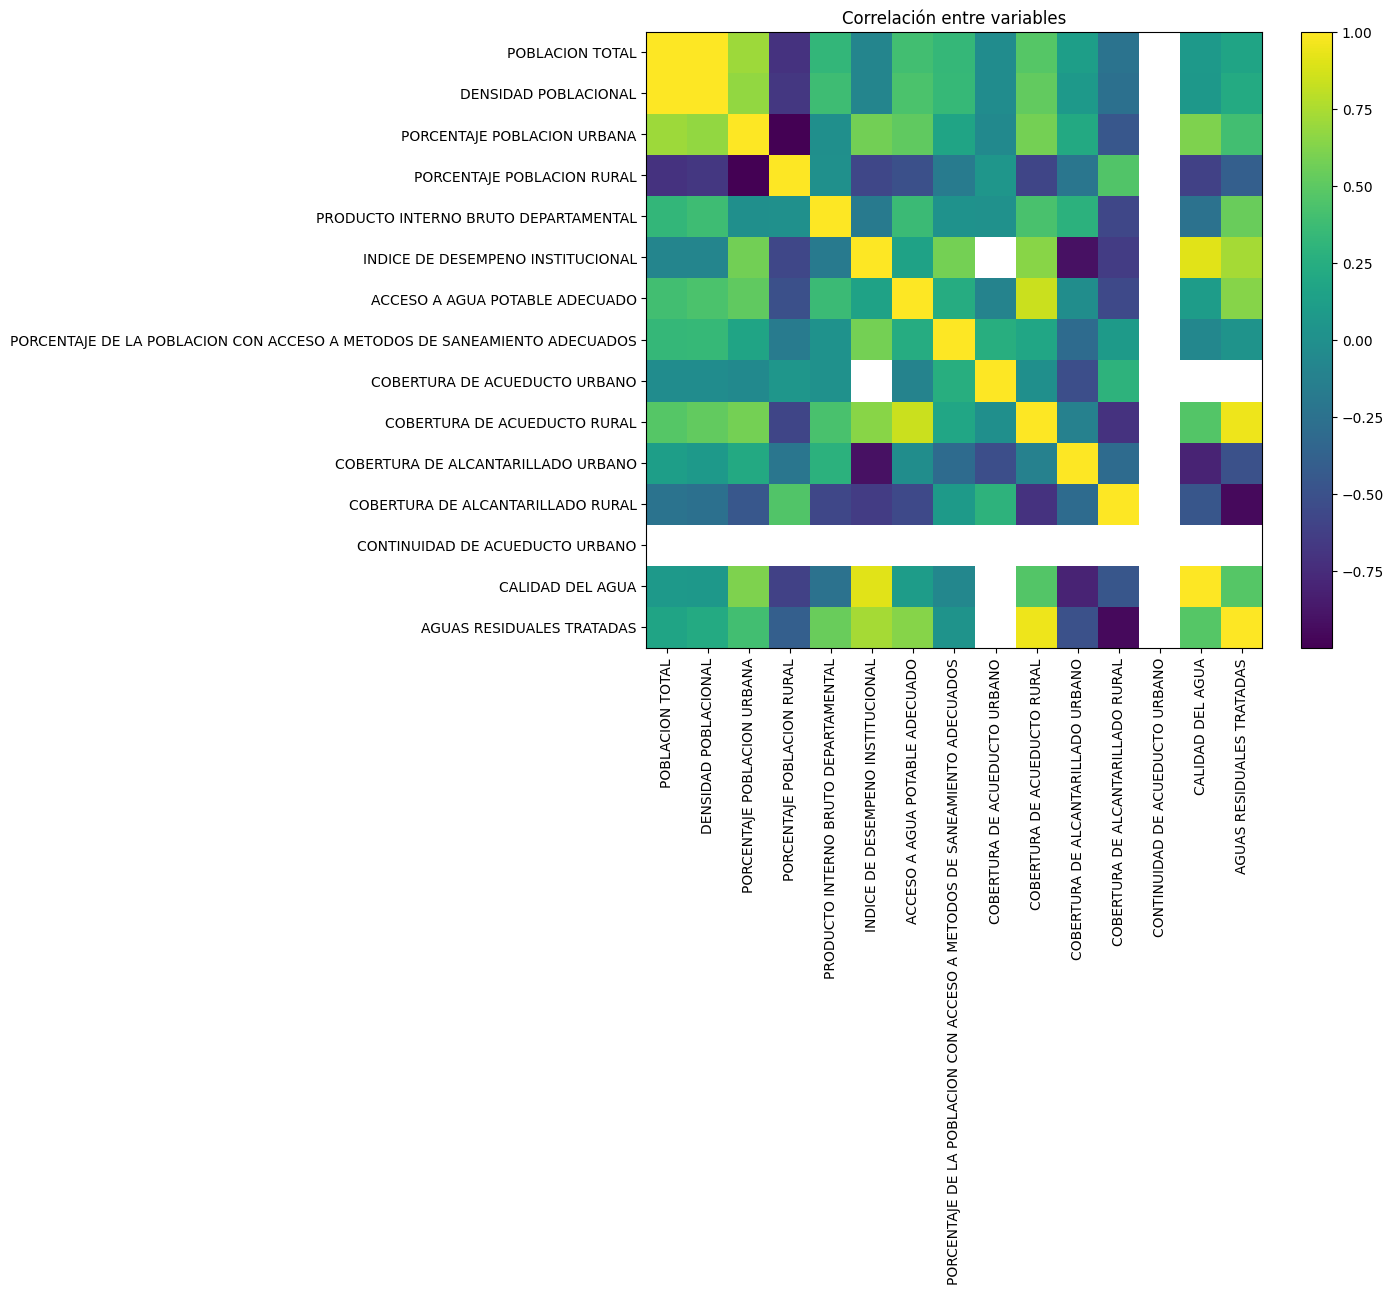

In [ ]:
import matplotlib.pyplot as plt

corr = variables.corr(numeric_only=True)

plt.figure(figsize=(10,8))

plt.imshow(corr)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar()

plt.title("Correlación entre variables")

plt.show()

In [ ]:
!pip install xlsxwriter
import pandas as pd
import xlsxwriter # Ensure xlsxwriter is imported

print('='*70)
print('M9 - GENERANDO REPORTE EDA')
print('='*70)

# Obtener los resultados de EDA previamente calculados
descriptive_stats = df.describe().T
completeness_report = ((1-df.isnull().mean())*100).round(2).sort_values(ascending=False).to_frame(name='Completitud (%)')
records_by_year = df.groupby('Anio').size().to_frame(name='Registros')
coverage_by_municipality = df.groupby('Nodo').size().to_frame(name='Registros')

# Crear un escritor de Excel
output_filename = "07_EDA.xlsx"
with pd.ExcelWriter(output_filename, engine='xlsxwriter') as writer:
    descriptive_stats.to_excel(writer, sheet_name='Estadisticas Descriptivas')
    completeness_report.to_excel(writer, sheet_name='Completitud')
    records_by_year.to_excel(writer, sheet_name='Registros por Año')
    coverage_by_municipality.to_excel(writer, sheet_name='Cobertura por Municipio')

print(f"\nReporte EDA '{output_filename}' generado correctamente.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 8.1 MB/s eta 0:00:00
M9 - GENERANDO REPORTE EDA

Reporte EDA '07_EDA.xlsx' generado correctamente.


La matriz de correlación muestra las relaciones lineales entre las variables numéricas en su conjunto de datos. Aquí hay un desglose de lo que podemos observar:

* Correlaciones Positivas Fuertes (Amarillo/Verde claro): Esto indica que a medida que una variable aumenta, la otra tiende a aumentar también. Por ejemplo, 'POBLACION TOTAL' y 'DENSIDAD POBLACIONAL' muestran una correlación positiva muy fuerte, lo cual es esperado ya que la densidad se deriva de la población.

* Correlaciones Negativas Fuertes (Morado oscuro/Azul): Esto sugiere que a medida que una variable aumenta, la otra tiende a disminuir. Podemos ver una fuerte correlación negativa entre 'PORCENTAJE POBLACION URBANA' y 'PORCENTAJE POBLACION RURAL', lo cual tiene sentido ya que son porcentajes complementarios.

* Correlación Débil o Nula (Verde/Colores intermedios): Estas áreas sugieren una relación lineal pequeña o nula entre las variables.

* Valores Ausentes (Cuadrados Blancos): Las celdas en blanco corresponden a correlaciones no calculadas debido a la baja disponibilidad de observaciones compartidas entre algunas variables. Este comportamiento está asociado a la naturaleza de las fuentes oficiales, donde ciertos indicadores son publicados únicamente para años específicos, reduciendo la cantidad de registros disponibles para estimar relaciones estadísticas confiables.

En conjunto, la matriz de correlación permite identificar relaciones lineales entre los indicadores demográficos, económicos y de servicios públicos incorporados en la Capa de Gobernanza. Asimismo, evidencia las limitaciones derivadas de la disponibilidad temporal de algunos indicadores, aspecto que deberá considerarse durante la integración con el Dataset Maestro y en las etapas posteriores de modelado predictivo del Framework.

OBSERVACIÓN

La matriz de correlación permite identificar las relaciones lineales existentes entre las variables numéricas de la Capa de Gobernanza. Se observa una fuerte correlación positiva entre la población total y la densidad poblacional, comportamiento esperado debido a la estrecha relación existente entre ambas variables. De igual forma, se identifica una fuerte correlación negativa entre el porcentaje de población urbana y el porcentaje de población rural, dado que representan componentes complementarios de la distribución poblacional.

Las celdas en blanco corresponden a correlaciones no calculadas debido a la limitada disponibilidad de observaciones compartidas entre algunas variables, como el Índice de Desempeño Institucional, la Continuidad del Acueducto Urbano, la Calidad del Agua y las Aguas Residuales Tratadas. Esta situación obedece a que dichos indicadores son publicados únicamente para determinados periodos por las entidades oficiales, reduciendo el número de registros disponibles para el cálculo de correlaciones estadísticamente representativas.

En conjunto, la matriz proporciona una visión general de las relaciones existentes entre los indicadores demográficos, económicos y de servicios públicos, permitiendo identificar variables relacionadas y evidenciando las limitaciones derivadas de la cobertura temporal de algunas fuentes de información. Estos resultados constituyen un insumo importante para la integración de la Capa de Gobernanza con el Dataset Maestro y para el desarrollo posterior de modelos analíticos y predictivos del Framework.

## **M10 – README**

In [ ]:
# ============================================================
# M10 - README
# Generación automática
# ============================================================

readme = f"""# {NOMBRE_CAPA}

## Framework V7 - Ciencia de Datos para la Gestión Hídrica

### Información general

| Campo | Valor |
|--------|-------|
| Capa | {NOMBRE_CAPA} |
| Código | {CODIGO_CAPA} |
| Versión | {VERSION} |
| Responsable | {RESPONSABLE} |

---

## Descripción

La Capa de Gobernanza consolida indicadores demográficos, económicos e institucionales asociados a los municipios objeto de estudio del Framework para la Gestión Hídrica.

La información fue integrada a partir de múltiples conjuntos de datos abiertos publicados por la Gobernación de Cundinamarca y posteriormente transformada a un formato tabular maestro con un registro por municipio y año.

Esta capa permite complementar la información climática, hidráulica y de percepción incorporando variables relacionadas con el contexto socioeconómico e institucional de cada territorio.

---

## Cobertura

Municipios incluidos

- CHIA
- SOPO
- TOCANCIPA
- VILLAPINZON

Cobertura temporal

2020 - 2024

Número de registros

{len(df)}

Número de variables

{len(df.columns)}

---

## Variables principales

- POBLACION TOTAL
- DENSIDAD POBLACIONAL
- PORCENTAJE POBLACION URBANA
- PORCENTAJE POBLACION RURAL
- PRODUCTO INTERNO BRUTO DEPARTAMENTAL
- INDICE DE DESEMPENO INSTITUCIONAL
- ACCESO A AGUA POTABLE ADECUADO
- PORCENTAJE DE LA POBLACION CON ACCESO A METODOS DE SANEAMIENTO ADECUADOS
- COBERTURA DE ACUEDUCTO URBANO
- COBERTURA DE ACUEDUCTO RURAL
- COBERTURA DE ALCANTARILLADO URBANO
- COBERTURA DE ALCANTARILLADO RURAL
- CONTINUIDAD DE ACUEDUCTO URBANO
- CALIDAD DEL AGUA
- AGUAS RESIDUALES TRATADAS

---

## Transformaciones realizadas

- Integración de tres conjuntos de datos oficiales.
- Selección de indicadores de gobernanza relevantes para el proyecto.
- Filtrado de los municipios objeto de estudio.
- Conversión del formato largo a formato ancho mediante tabla pivote.
- Estandarización de nombres de municipios.
- Conversión de tipos de datos.
- Generación de identificadores del Framework.
- Validación estructural.
- Generación de metadatos.
- Elaboración del diccionario de datos.
- Auditoría de calidad.
- Construcción de indicadores descriptivos.
- Análisis exploratorio de datos (EDA).

---

## Fuentes de información

Portal de Datos Abiertos de Cundinamarca

https://datosmintic-cundinamarca-map.hub.arcgis.com/

Conjuntos utilizados

- SERVICIOS_PUBLICOS.xlsx
- ECONOMIA.xlsx
- DESCRIPCION_GENERAL.xlsx

---

## Archivo generado

01_Capa_Gobernanza_V1.xlsx

---

Framework V7
Proyecto de Maestría
Ciencia de Datos aplicada a la Gestión Hídrica
"""

with open("08_README.md","w",encoding="utf-8") as f:
    f.write(readme)

print("="*70)
print("README generado correctamente")
print("="*70)
print("Archivo: 08_README.md")

README generado correctamente
Archivo: 08_README.md


## **Exportación Final**

In [ ]:
print("="*70)
print("EXPORTACIÓN FINAL")
print("="*70)

archivo_salida = "02_Capa_Gobernanza_Framework.xlsx"

df.to_excel(
    archivo_salida,
    index=False,
    sheet_name="Gobernanza"
)

print()
print("Archivo exportado correctamente.")
print(archivo_salida)
print("Registros :", len(df))
print("Columnas  :", len(df.columns))